In [42]:
from sklearn.preprocessing import MinMaxScaler , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df = pd.read_csv("Real_House_Data.csv")
df

,Property_Area,Bedrooms,Bathrooms,Floors,Year_Built,Property_Age,Renovation_Status,Lot_Size,Distance_to_City_Center,Neighborhood_Quality_Score,...,Property_Type,Construction_Quality_Rating,Energy_Efficiency_Score,Water_Supply_Reliability,Electricity_Supply_Reliability,Internet_Availability_Score,Green_Space_Availability_Index,Flood_Risk_Index,Noise_Pollution_Level,Price
0,2684.821829,5,5,2,2018,7,Yes,3776.225833,33.354414,8,...,Independent House,2,NaN,4,5,8,51.585174,42.269855,51.872234,1.203248e+07
1,1772.507662,1,1,1,1970,55,No,3343.248191,21.896193,5,...,Apartment,5,5.0,3,5,8,36.729241,66.331214,66.489083,7.425842e+06
2,1655.959623,2,1,1,2015,10,No,2856.909759,25.358405,2,...,Apartment,8,2.0,3,5,10,20.020779,79.023068,68.119671,5.734560e+06
3,1655.979127,1,1,1,1976,49,Yes,2998.753552,22.062582,6,...,Apartment,5,10.0,9,2,4,40.894197,53.745498,60.449037,8.258959e+06
4,4879.446067,3,2,3,1999,26,No,5373.625371,22.449431,2,...,Villa,5,9.0,1,10,2,22.463846,86.873374,61.445164,2.128731e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2302.741825,2,2,1,1994,31,No,3766.541599,10.708116,9,...,Villa,9,3.0,7,6,2,72.799026,36.744778,43.506769,1.173157e+07
9996,1373.561786,3,3,2,1994,31,No,2271.349068,11.949866,4,...,Villa,3,10.0,9,3,8,25.805114,89.150722,66.396883,6.458641e+06
9997,1191.319333,2,2,2,2022,3,No,2748.265662,23.944225,2,...,Independent House,8,2.0,10,4,8,0.000000,91.177488,76.934267,4.891362e+06
9998,2811.384485,6,5,1,1970,55,No,NaN,7.170758,8,...,Villa,1,1.0,1,8,7,54.362379,47.010666,53.486149,1.353664e+07


In [44]:
df.isnull().sum()

Property_Area                       0
Bedrooms                            0
Bathrooms                           0
Floors                              0
Year_Built                          0
Property_Age                        0
Renovation_Status                   0
Lot_Size                          500
Distance_to_City_Center             0
Neighborhood_Quality_Score          0
Crime_Rate_Index                    0
Nearby_School_Rating              500
Hospital_Proximity_km               0
Shopping_Center_Proximity_km        0
Public_Transport_Accessibility      0
Parking_Availability                0
Property_Type                       0
Construction_Quality_Rating         0
Energy_Efficiency_Score           500
Water_Supply_Reliability            0
Electricity_Supply_Reliability      0
Internet_Availability_Score         0
Green_Space_Availability_Index    500
Flood_Risk_Index                    0
Noise_Pollution_Level               0
Price                               0
dtype: int64

In [45]:
#Lot_Size Fixed
df['Lot_Size'] = df.groupby(['Property_Type', 'Bedrooms'])['Lot_Size'].transform(lambda x: x.fillna(x.mean()))

In [46]:
#Nearby School Rating Fixed
df['Neighborhood_bin'] = pd.cut(df['Neighborhood_Quality_Score'], bins=5)

df['Nearby_School_Rating'] = df.groupby('Neighborhood_bin' , observed = True)['Nearby_School_Rating'].transform(
    lambda x: x.fillna(x.mean())
)

In [47]:
#Energy Score Fixed
df['Age_bin'] = pd.cut(df['Property_Age'], bins=5)

df['Energy_Efficiency_Score'] = df.groupby(['Age_bin', 'Construction_Quality_Rating'] , observed = True)['Energy_Efficiency_Score'].transform(
    lambda x: x.fillna(x.mean())
)

In [48]:
#Green Availability Fixed
df['Distance_bin'] = pd.cut(df['Distance_to_City_Center'], bins=5)

df['Green_Space_Availability_Index'] = df.groupby('Distance_bin' , observed = True)['Green_Space_Availability_Index'].transform(
    lambda x: x.fillna(x.mean())
)

In [49]:
print(df.isnull().sum())
df_new = df.drop(columns = ['Neighborhood_bin' , 'Age_bin' , 'Distance_bin' , 'Year_Built'])
df_new

Property_Area                     0
Bedrooms                          0
Bathrooms                         0
Floors                            0
Year_Built                        0
Property_Age                      0
Renovation_Status                 0
Lot_Size                          0
Distance_to_City_Center           0
Neighborhood_Quality_Score        0
Crime_Rate_Index                  0
Nearby_School_Rating              0
Hospital_Proximity_km             0
Shopping_Center_Proximity_km      0
Public_Transport_Accessibility    0
Parking_Availability              0
Property_Type                     0
Construction_Quality_Rating       0
Energy_Efficiency_Score           0
Water_Supply_Reliability          0
Electricity_Supply_Reliability    0
Internet_Availability_Score       0
Green_Space_Availability_Index    0
Flood_Risk_Index                  0
Noise_Pollution_Level             0
Price                             0
Neighborhood_bin                  0
Age_bin                     

,Property_Area,Bedrooms,Bathrooms,Floors,Year_Built,Property_Age,Renovation_Status,Lot_Size,Distance_to_City_Center,Neighborhood_Quality_Score,...,Property_Type,Construction_Quality_Rating,Energy_Efficiency_Score,Water_Supply_Reliability,Electricity_Supply_Reliability,Internet_Availability_Score,Green_Space_Availability_Index,Flood_Risk_Index,Noise_Pollution_Level,Price
0,2684.821829,5,5,2,2018,7,Yes,3776.225833,33.354414,8,...,Independent House,2,5.769608,4,5,8,51.585174,42.269855,51.872234,1.203248e+07
1,1772.507662,1,1,1,1970,55,No,3343.248191,21.896193,5,...,Apartment,5,5.000000,3,5,8,36.729241,66.331214,66.489083,7.425842e+06
2,1655.959623,2,1,1,2015,10,No,2856.909759,25.358405,2,...,Apartment,8,2.000000,3,5,10,20.020779,79.023068,68.119671,5.734560e+06
3,1655.979127,1,1,1,1976,49,Yes,2998.753552,22.062582,6,...,Apartment,5,10.000000,9,2,4,40.894197,53.745498,60.449037,8.258959e+06
4,4879.446067,3,2,3,1999,26,No,5373.625371,22.449431,2,...,Villa,5,9.000000,1,10,2,22.463846,86.873374,61.445164,2.128731e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2302.741825,2,2,1,1994,31,No,3766.541599,10.708116,9,...,Villa,9,3.000000,7,6,2,72.799026,36.744778,43.506769,1.173157e+07
9996,1373.561786,3,3,2,1994,31,No,2271.349068,11.949866,4,...,Villa,3,10.000000,9,3,8,25.805114,89.150722,66.396883,6.458641e+06
9997,1191.319333,2,2,2,2022,3,No,2748.265662,23.944225,2,...,Independent House,8,2.000000,10,4,8,0.000000,91.177488,76.934267,4.891362e+06
9998,2811.384485,6,5,1,1970,55,No,4906.370154,7.170758,8,...,Villa,1,1.000000,1,8,7,54.362379,47.010666,53.486149,1.353664e+07


In [50]:

# Basic info
print(df.head())
print(df.info())
print(df.describe())

# Missing values
print(df.isnull().sum())

   Property_Area  Bedrooms  Bathrooms  Floors  Year_Built  Property_Age  \
0    2684.821829         5          5       2        2018             7   
1    1772.507662         1          1       1        1970            55   
2    1655.959623         2          1       1        2015            10   
3    1655.979127         1          1       1        1976            49   
4    4879.446067         3          2       3        1999            26   

  Renovation_Status     Lot_Size  Distance_to_City_Center  \
0               Yes  3776.225833                33.354414   
1                No  3343.248191                21.896193   
2                No  2856.909759                25.358405   
3               Yes  2998.753552                22.062582   
4                No  5373.625371                22.449431   

   Neighborhood_Quality_Score  ...  Water_Supply_Reliability  \
0                           8  ...                         4   
1                           5  ...                    

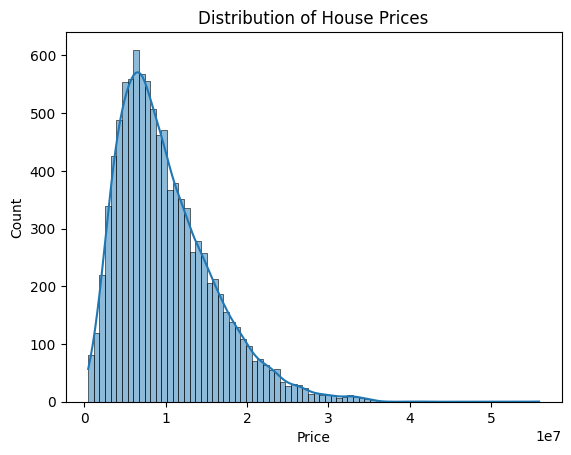

1.1047004945340464


In [51]:
sns.histplot(df["Price"], kde=True)
plt.title("Distribution of House Prices")
plt.show()
print(df["Price"].skew())

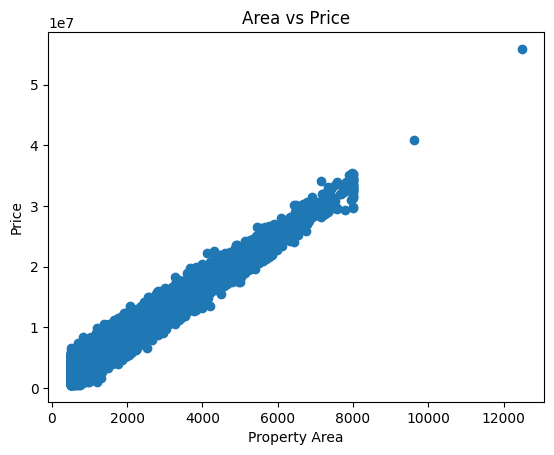

In [52]:
plt.scatter(df["Property_Area"], df["Price"])
plt.xlabel("Property Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

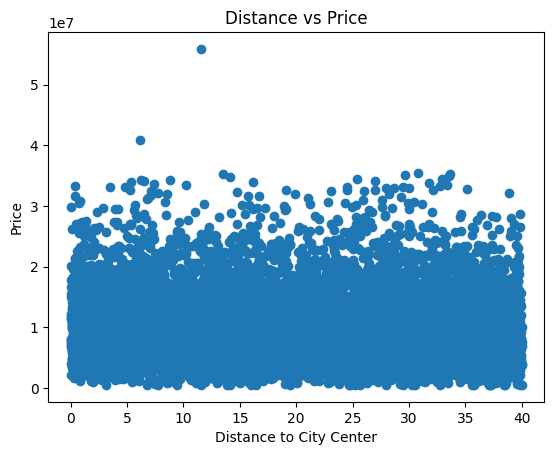

In [53]:
plt.scatter(df["Distance_to_City_Center"], df["Price"])
plt.xlabel("Distance to City Center")
plt.ylabel("Price")
plt.title("Distance vs Price")
plt.show()

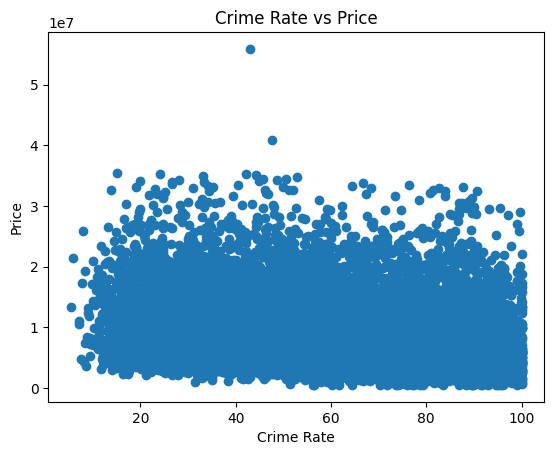

In [54]:
plt.scatter(df["Crime_Rate_Index"], df["Price"])
plt.xlabel("Crime Rate")
plt.ylabel("Price")
plt.title("Crime Rate vs Price")
plt.show()

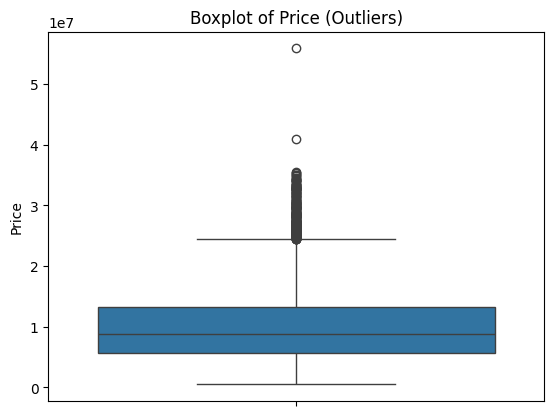

In [55]:
plt.figure()
sns.boxplot(df["Price"])
plt.title("Boxplot of Price (Outliers)")
plt.show()

In [56]:
#One-Hot Encoding Used 

cat_col = df_new.select_dtypes(include='object').columns
df_new = pd.get_dummies(df_new , columns = cat_col , drop_first = True)
#  drop-first Function takes 1 value of the categorical column as a 'reference'

df_new

,Property_Area,Bedrooms,Bathrooms,Floors,Year_Built,Property_Age,Lot_Size,Distance_to_City_Center,Neighborhood_Quality_Score,Crime_Rate_Index,...,Water_Supply_Reliability,Electricity_Supply_Reliability,Internet_Availability_Score,Green_Space_Availability_Index,Flood_Risk_Index,Noise_Pollution_Level,Price,Renovation_Status_Yes,Property_Type_Independent House,Property_Type_Villa
0,2684.821829,5,5,2,2018,7,3776.225833,33.354414,8,35.239294,...,4,5,8,51.585174,42.269855,51.872234,1.203248e+07,True,True,False
1,1772.507662,1,1,1,1970,55,3343.248191,21.896193,5,63.487365,...,3,5,8,36.729241,66.331214,66.489083,7.425842e+06,False,False,False
2,1655.959623,2,1,1,2015,10,2856.909759,25.358405,2,83.749235,...,3,5,10,20.020779,79.023068,68.119671,5.734560e+06,False,False,False
3,1655.979127,1,1,1,1976,49,2998.753552,22.062582,6,55.247941,...,9,2,4,40.894197,53.745498,60.449037,8.258959e+06,True,False,False
4,4879.446067,3,2,3,1999,26,5373.625371,22.449431,2,77.985565,...,1,10,2,22.463846,86.873374,61.445164,2.128731e+07,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2302.741825,2,2,1,1994,31,3766.541599,10.708116,9,30.634170,...,7,6,2,72.799026,36.744778,43.506769,1.173157e+07,False,False,True
9996,1373.561786,3,3,2,1994,31,2271.349068,11.949866,4,58.222542,...,9,3,8,25.805114,89.150722,66.396883,6.458641e+06,False,False,True
9997,1191.319333,2,2,2,2022,3,2748.265662,23.944225,2,84.525293,...,10,4,8,0.000000,91.177488,76.934267,4.891362e+06,False,True,False
9998,2811.384485,6,5,1,1970,55,4906.370154,7.170758,8,35.927063,...,1,8,7,54.362379,47.010666,53.486149,1.353664e+07,False,False,True


In [57]:
num_cols = [col for col in df_new.columns if df_new[col].nunique() > 2]

for col in num_cols:
    Q1 = df_new[col].quantile(0.25)
    Q3 = df_new[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df_new = df_new[(df_new[col] >= lower) & (df_new[col] <= upper)]

df_new

,Property_Area,Bedrooms,Bathrooms,Floors,Year_Built,Property_Age,Lot_Size,Distance_to_City_Center,Neighborhood_Quality_Score,Crime_Rate_Index,...,Water_Supply_Reliability,Electricity_Supply_Reliability,Internet_Availability_Score,Green_Space_Availability_Index,Flood_Risk_Index,Noise_Pollution_Level,Price,Renovation_Status_Yes,Property_Type_Independent House,Property_Type_Villa
0,2684.821829,5,5,2,2018,7,3776.225833,33.354414,8,35.239294,...,4,5,8,51.585174,42.269855,51.872234,1.203248e+07,True,True,False
1,1772.507662,1,1,1,1970,55,3343.248191,21.896193,5,63.487365,...,3,5,8,36.729241,66.331214,66.489083,7.425842e+06,False,False,False
2,1655.959623,2,1,1,2015,10,2856.909759,25.358405,2,83.749235,...,3,5,10,20.020779,79.023068,68.119671,5.734560e+06,False,False,False
3,1655.979127,1,1,1,1976,49,2998.753552,22.062582,6,55.247941,...,9,2,4,40.894197,53.745498,60.449037,8.258959e+06,True,False,False
5,3153.592273,6,5,2,2002,23,4064.463530,35.406036,10,20.723259,...,10,10,9,91.836212,19.668196,53.206428,1.445879e+07,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2302.741825,2,2,1,1994,31,3766.541599,10.708116,9,30.634170,...,7,6,2,72.799026,36.744778,43.506769,1.173157e+07,False,False,True
9996,1373.561786,3,3,2,1994,31,2271.349068,11.949866,4,58.222542,...,9,3,8,25.805114,89.150722,66.396883,6.458641e+06,False,False,True
9997,1191.319333,2,2,2,2022,3,2748.265662,23.944225,2,84.525293,...,10,4,8,0.000000,91.177488,76.934267,4.891362e+06,False,True,False
9998,2811.384485,6,5,1,1970,55,4906.370154,7.170758,8,35.927063,...,1,8,7,54.362379,47.010666,53.486149,1.353664e+07,False,False,True


In [58]:
df_new.to_csv("Final_Data.csv" , index = False)

In [59]:
x = df_new.drop('Price' , axis=1)
y = df_new['Price']

In [60]:
x_train  , x_test , y_train , y_test = train_test_split( x , y , test_size = 0.4 , random_state = 42)

In [62]:
#Although all Columns are Already Numeric , Dummy Columns (Encoded Columns) are NOT to be Scaled

num_cols = x_train.select_dtypes(include=['int64', 'float64']).columns
num_cols = [col for col in num_cols if x_train[col].nunique() > 2]
num_cols

['Property_Area',
 'Bedrooms',
 'Bathrooms',
 'Floors',
 'Year_Built',
 'Property_Age',
 'Lot_Size',
 'Distance_to_City_Center',
 'Neighborhood_Quality_Score',
 'Crime_Rate_Index',
 'Nearby_School_Rating',
 'Hospital_Proximity_km',
 'Shopping_Center_Proximity_km',
 'Public_Transport_Accessibility',
 'Construction_Quality_Rating',
 'Energy_Efficiency_Score',
 'Water_Supply_Reliability',
 'Electricity_Supply_Reliability',
 'Internet_Availability_Score',
 'Green_Space_Availability_Index',
 'Flood_Risk_Index',
 'Noise_Pollution_Level']

In [63]:
#Scaling The Data
scale = StandardScaler()
x_train[num_cols] = scale.fit_transform(x_train[num_cols])
x_test[num_cols] = scale.fit_transform(x_test[num_cols])

In [64]:
model = ElasticNet(alpha=0.1, l1_ratio=0.7)

In [65]:
#Backward Elimination Used to select Features 

sfs = SequentialFeatureSelector(model,n_features_to_select=19, direction='backward')

In [66]:
sfs.fit_transform(x_train , y_train)

array([[-0.39834199, -0.18271927, -0.26326411, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.30117764, -0.96605881,  0.30777279, ...,  1.        ,
         0.        ,  1.        ],
       [-0.93543496, -0.96605881,  1.19605242, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.43361834, -0.96605881,  0.62501551, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.81492657,  2.16729935,  0.1808757 , ...,  0.        ,
         0.        ,  1.        ],
       [ 0.71572979,  0.60062027,  0.81536115, ...,  0.        ,
         0.        ,  0.        ]], shape=(5226, 19))

In [67]:
x_train = sfs.transform(x_train)
x_test = sfs.transform(x_test)

In [68]:
selected_features = x.columns[sfs.get_support()]
print(selected_features)

Index(['Property_Area', 'Bathrooms', 'Year_Built', 'Property_Age',
       'Distance_to_City_Center', 'Neighborhood_Quality_Score',
       'Crime_Rate_Index', 'Nearby_School_Rating',
       'Shopping_Center_Proximity_km', 'Public_Transport_Accessibility',
       'Parking_Availability', 'Construction_Quality_Rating',
       'Energy_Efficiency_Score', 'Green_Space_Availability_Index',
       'Flood_Risk_Index', 'Noise_Pollution_Level', 'Renovation_Status_Yes',
       'Property_Type_Independent House', 'Property_Type_Villa'],
      dtype='object')


In [69]:
model.fit(x_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.1
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.7
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [70]:
y_pred = model.predict(x_test)
y_pred

array([11699803.71860018, 13206691.92998494, 17205760.44865421, ...,
        7723067.85750762,  7274157.07253496,  4057041.36280132],
      shape=(3484,))

In [71]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

mean_y = y.mean()

print("Mean of target:", mean_y)
print("RMSE %:", (rmse / mean_y) * 100)
print("MAE %:", (mae / mean_y) * 100)

print("Min:", y.min())
print("Max:", y.max())
print("Mean:", y.mean())

RMSE: 833762.0060593038
MAE: 664886.2272131962
Mean of target: 8514450.099310054
RMSE %: 9.792317722630914
MAE %: 7.808915660531894
Min: 500000.0
Max: 20483881.091685265
Mean: 8514450.099310054


In [72]:
r2 = r2_score(y_test , y_pred) 
print("R2 Score : " , r2)

R2 Score :  0.9609382992083996


In [73]:
y_train_pred = model.predict(x_train)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_pred)

print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train R2: 0.9624880473200264
Test R2: 0.9609382992083996


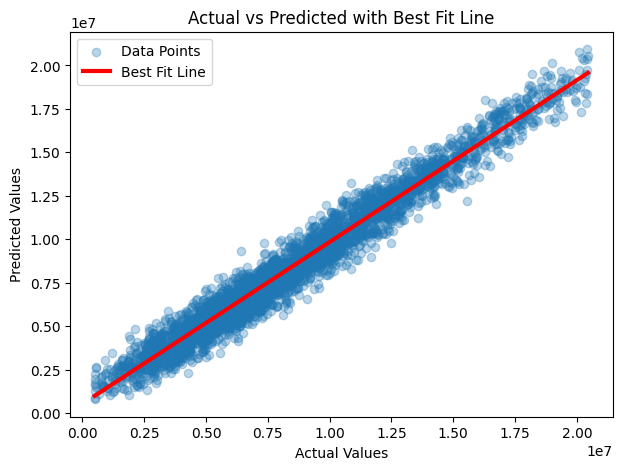

In [74]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

# Convert to numpy
x = np.array(y_test)
y = np.array(y_pred)

# Scatter plot
plt.scatter(x, y, alpha=0.3, label='Data Points')

# Best fit line
slope, intercept = np.polyfit(x, y, 1)
line = slope * x + intercept

# Sort for smooth line
sorted_idx = np.argsort(x)

plt.plot(x[sorted_idx], line[sorted_idx],
         color='red', linewidth=3, label='Best Fit Line')

# Labels
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted with Best Fit Line")
plt.legend()

plt.show()

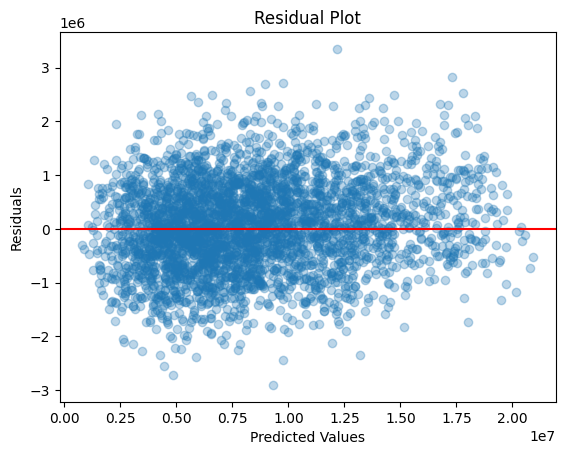

In [75]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

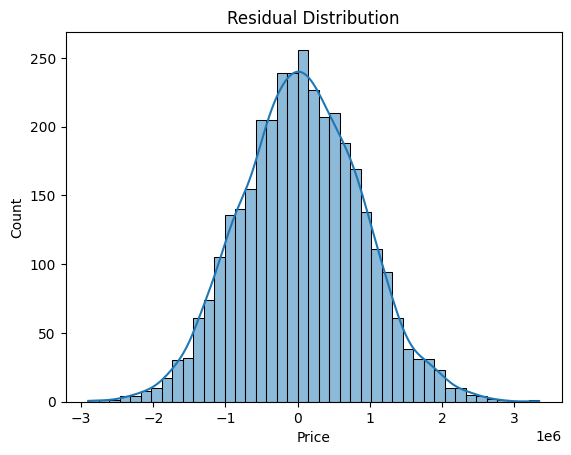

In [76]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()